In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib widget
from sklearn import preprocessing

In [2]:
data = pd.read_csv('loan.csv')

In [3]:
data.head(-1)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0.0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1.0,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0.0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0.0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0.0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
592,LP002974,Male,Yes,0.0,Graduate,No,3232,1950.0,108.0,360.0,1.0,Rural,Y
593,LP002978,Female,No,0.0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
594,LP002979,Male,Yes,3.0,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
595,LP002983,Male,Yes,1.0,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y


In [4]:
data.isnull().sum()

Loan_ID               0
Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [5]:
data.drop('Loan_ID',axis=1,inplace=True)

In [6]:
data.dtypes == 'object'

Gender                True
Married               True
Dependents           False
Education             True
Self_Employed         True
ApplicantIncome      False
CoapplicantIncome    False
LoanAmount           False
Loan_Amount_Term     False
Credit_History       False
Property_Area         True
Loan_Status           True
dtype: bool

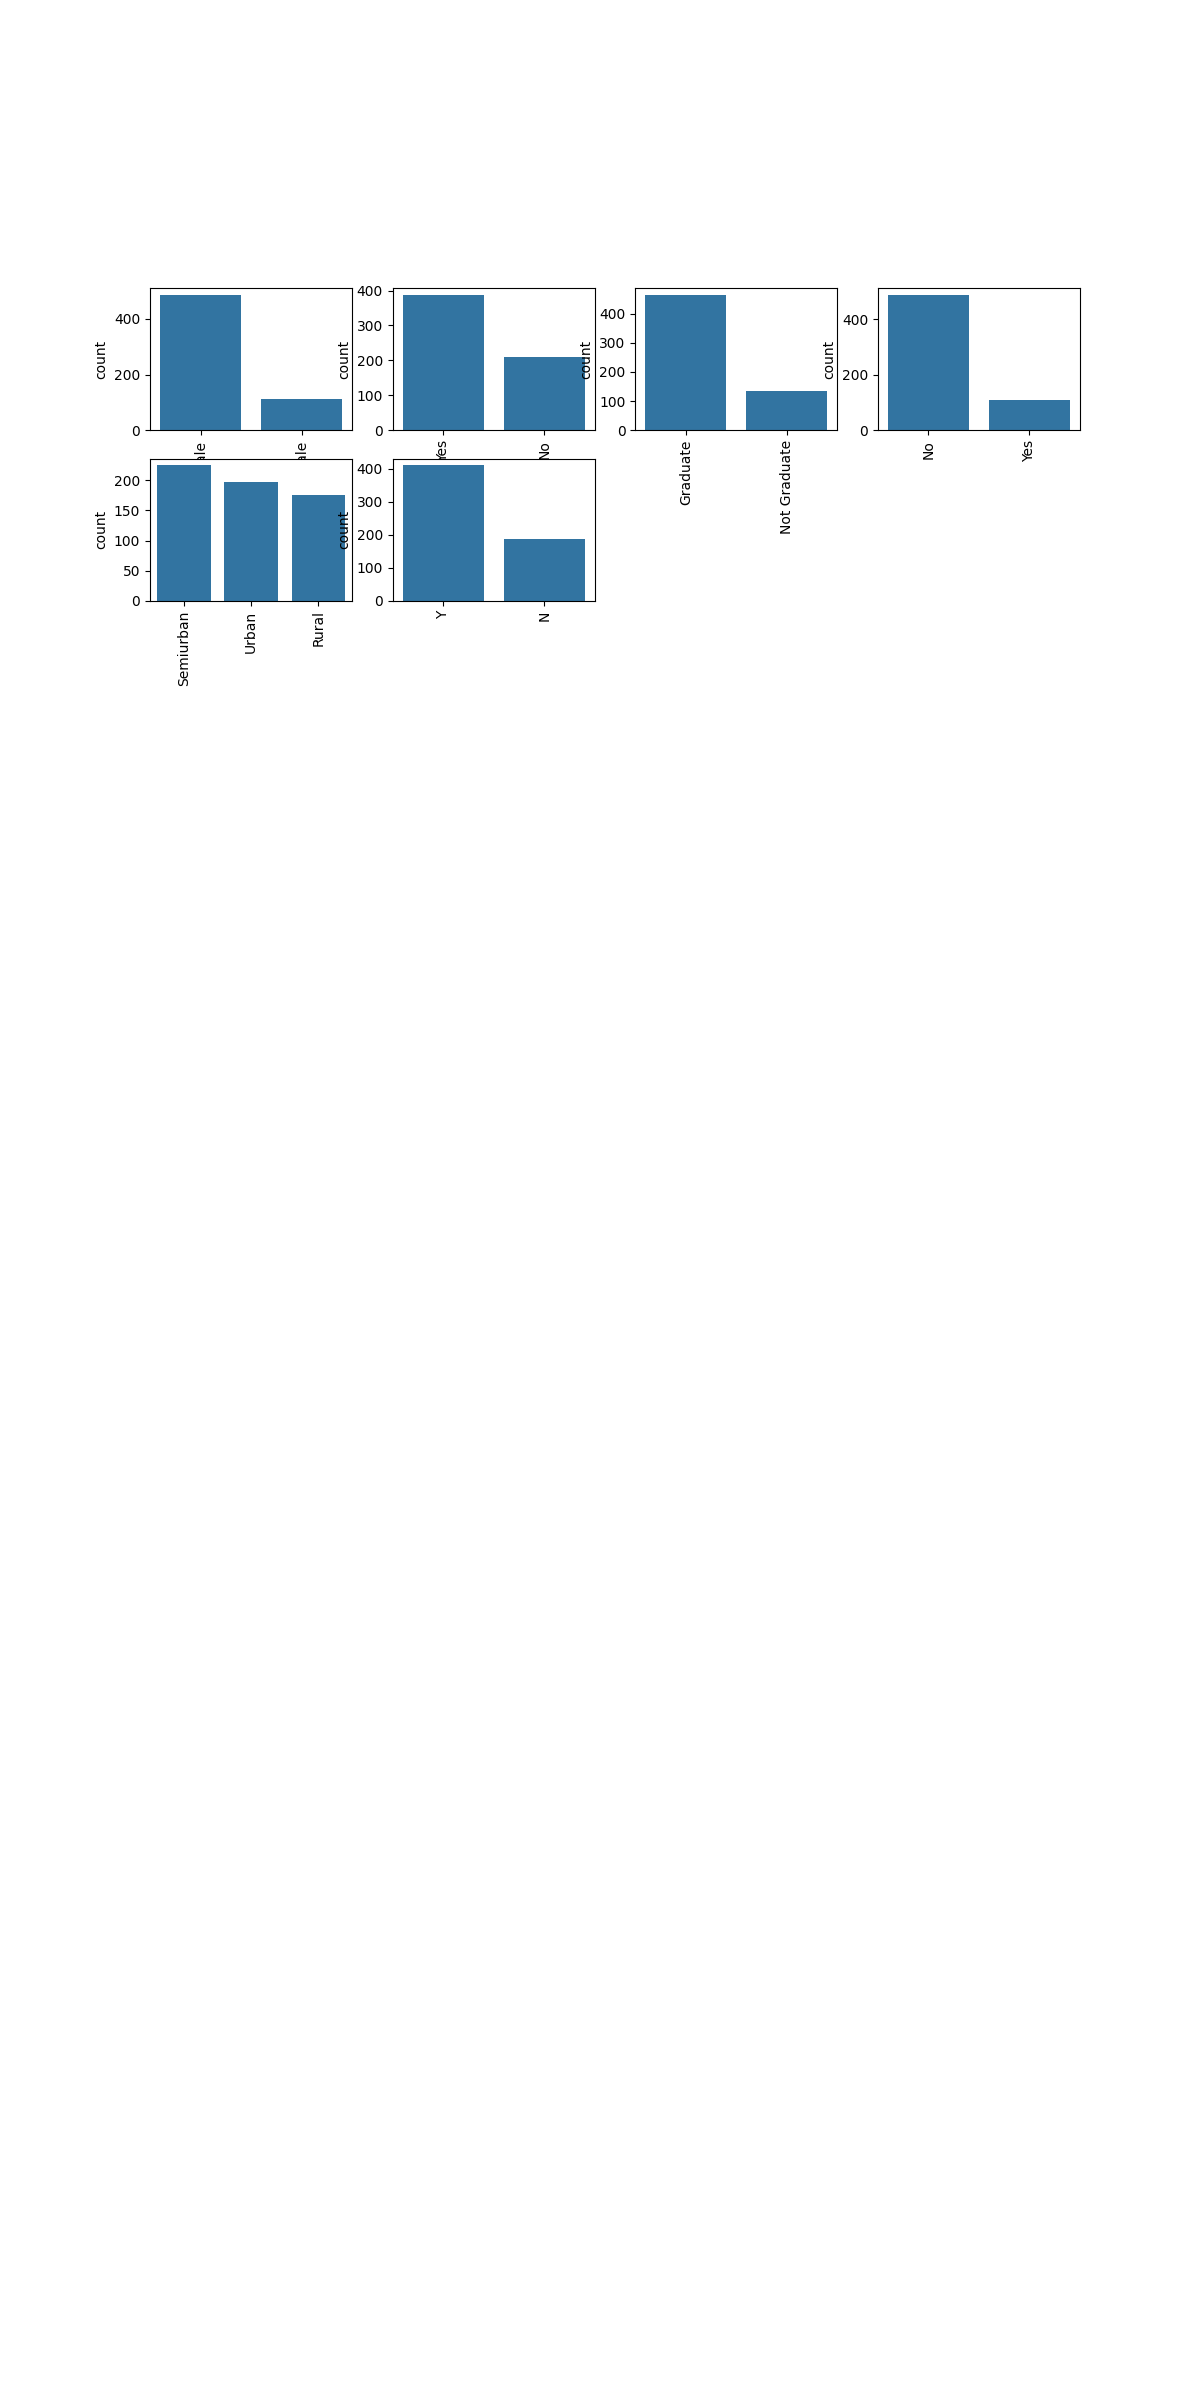

In [7]:
obj = (data.dtypes == 'object')
object_cols = list(obj[obj].index)
plt.close()
plt.figure(figsize=(12,24))
index = 1

for col in object_cols:
    y = data[col].value_counts()
    plt.subplot(11,4,index)
    plt.xticks(rotation = 90)
    sns.barplot(x= list(y.index), y = y)
    index += 1


In [8]:
lable_encoder = preprocessing.LabelEncoder()
for col in list(obj[obj].index):
    data[col] = lable_encoder.fit_transform(data[col])

In [9]:
data.head

<bound method NDFrame.head of      Gender  Married  Dependents  Education  Self_Employed  ApplicantIncome  \
0         1        0         0.0          0              0             5849   
1         1        1         1.0          0              0             4583   
2         1        1         0.0          0              1             3000   
3         1        1         0.0          1              0             2583   
4         1        0         0.0          0              0             6000   
..      ...      ...         ...        ...            ...              ...   
593       0        0         0.0          0              0             2900   
594       1        1         3.0          0              0             4106   
595       1        1         1.0          0              0             8072   
596       1        1         2.0          0              0             7583   
597       0        0         0.0          0              1             4583   

     CoapplicantIncom

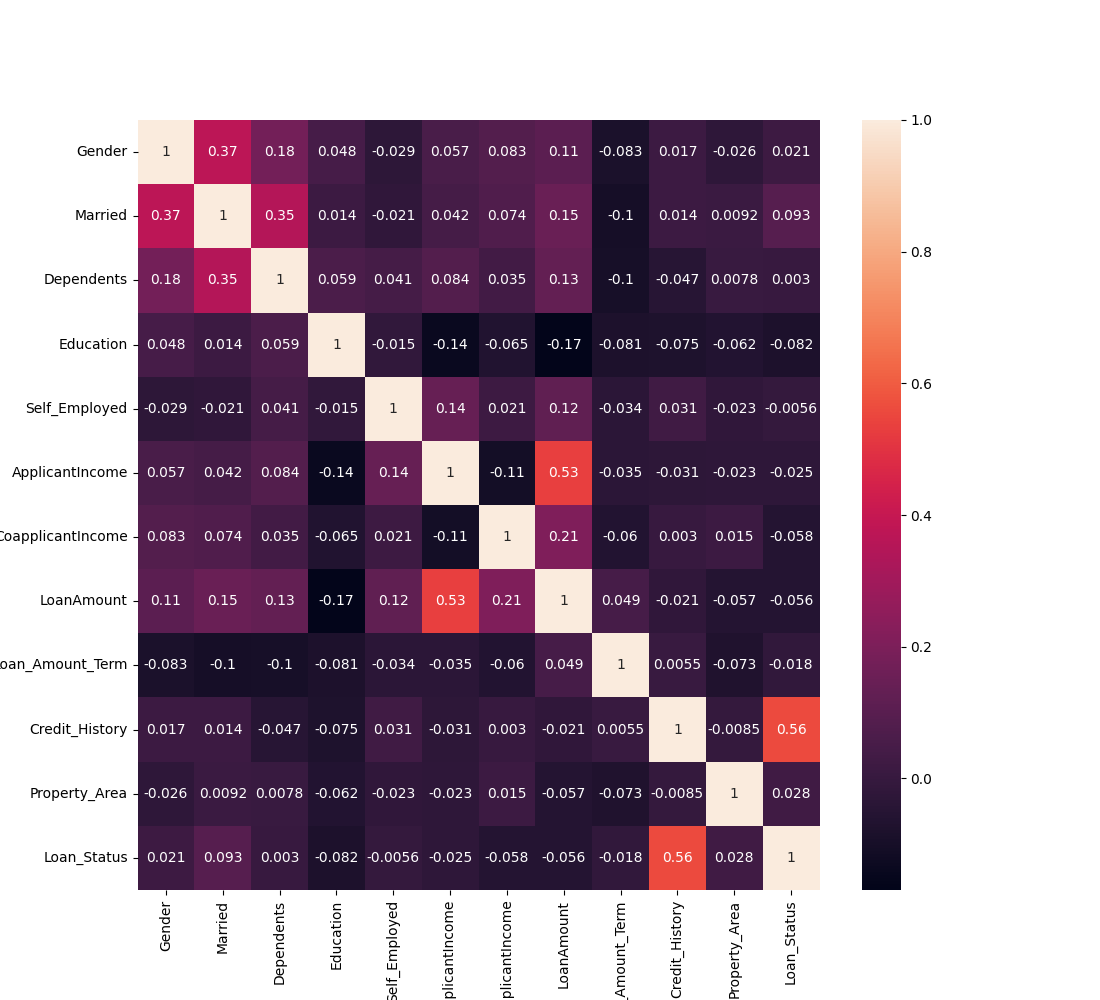

In [10]:
plt.close()
plt.figure(figsize=(11,10))

sns.heatmap(data.corr(),annot=True)
plt.show()

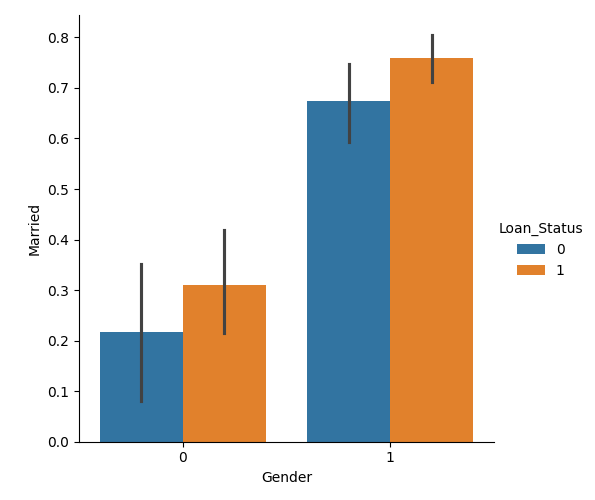

In [21]:
sns.catplot( x = 'Gender', y = 'Married',
            hue='Loan_Status',
            kind='bar',
            data=data
)

In [11]:
data.isnull().sum()

Gender                0
Married               0
Dependents           12
Education             0
Self_Employed         0
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           21
Loan_Amount_Term     14
Credit_History       49
Property_Area         0
Loan_Status           0
dtype: int64

In [12]:
for col in data.columns:
    data[col] = data[col].fillna(data[col].mean())

data.isna().sum()    

Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [13]:
from sklearn.model_selection import train_test_split

x = data.drop(['Loan_Status'], axis=1)
y = data['Loan_Status'] 

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((478, 11), (120, 11), (478,), (120,))

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

knn = KNeighborsClassifier(n_neighbors=3)
lg = LogisticRegression()
dc = DecisionTreeClassifier()

for clf in (knn,lg,dc):
    clf.max_iter = 10000
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_train)
    print("Accuracy score of",
        clf.__class__.__name__,  
        "=", 100 * metrics.accuracy_score(y_train,
                                          y_pred)
    )


Accuracy score of KNeighborsClassifier = 75.73221757322176
Accuracy score of LogisticRegression = 80.5439330543933
Accuracy score of DecisionTreeClassifier = 100.0


In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn import metrics

knn = KNeighborsClassifier()
lg = LogisticRegression()
dc = DecisionTreeClassifier()

for clf in (knn,lg,dc):
    clf.max_iter = 10000
    clf.fit(X_train,y_train)
    y_pred = clf.predict(X_test)
    print("Accuracy score of",
        clf.__class__.__name__,  
        "=", 100 * metrics.accuracy_score(y_test,
                                          y_pred)
    )


Accuracy score of KNeighborsClassifier = 70.83333333333334
Accuracy score of LogisticRegression = 82.5
Accuracy score of DecisionTreeClassifier = 69.16666666666667
